In [46]:
import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

# หากใช้ใน Google Colab ต้องติดตั้งไลบรารีก่อน
# !pip install earthengine-api folium matplotlib pandas

# ใน Google Colab ต้องใช้ ee.Authenticate() แทน earthengine authenticate เพราะ Colab ไม่มี CLI เหมือนเครื่อง Local
ee.Authenticate()

# ตรวจสอบและเริ่มต้นการเชื่อมต่อ GEE
try:
    ee.Initialize(project="ee-sakda-451407")
except Exception as e:
    ee.Authenticate() # หากยังไม่ได้ยืนยันตัวตน ให้ทำการยืนยัน
    ee.Initialize(project="ee-sakda-451407") 

In [59]:
# Step 1: Define Thailand geometry using FAO/GAUL dataset
# thailand = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level0')\
#     .filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))\
#     .geometry()

thailand = ee.Geometry.Polygon([
    [
        [98.5, 19.5], 
        [99.5, 19.5], 
        [99.5, 18.5], 
        [98.5, 18.5], 
        [98.5, 19.5]  
    ]
]);

date_start = ee.Date('2020-01-01')
date_end = ee.Date('2024-12-31')

# Step 2: Load FIRMS VIIRS fire data
firms = ee.ImageCollection('FIRMS')\
    .select('T21')\
    .filterDate(date_start, date_end)\
    .filterBounds(thailand)

# Step 3: Convert ImageCollection to FeatureCollection of fire points
def create_fire_points(image):
    fire_mask = image.select('T21').gt(0)\
        .set('system:time_start', image.get('system:time_start'))
    vectors = fire_mask.reduceToVectors(
        geometry=thailand,
        scale=375,
        geometryType='centroid',
        labelProperty='fire',
        maxPixels=1e9
    ).filterBounds(thailand)
    return vectors.map(lambda feature: feature.set('system:time_start', image.get('system:time_start')))

fire_points = firms.map(create_fire_points)
flattened_points = fire_points.flatten()

# Step 4: Function to count hotspots by week
def count_hotspots_by_week(fire_points, start_date, end_date):
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    weeks = ee.List.sequence(0, end.difference(start, 'week').floor())
    
    def count_week(week_offset):
        week_start = start.advance(week_offset, 'week')
        week_end = week_start.advance(1, 'week')
        weekly_points = fire_points.filterDate(week_start, week_end)
        count = weekly_points.size()
        return ee.Feature(None, {
            'week': week_start.format('YYYY-MM-dd'),
            'hotspot': count
        })
    
    return ee.FeatureCollection(weeks.map(count_week))

# Step 5: Generate weekly counts
weekly_hotspot_counts = count_hotspots_by_week(flattened_points, date_start, date_end)


In [60]:
# Step 9: Create a Folium map
def add_ee_layer(ee_object, vis_params, name):
    try:
        if isinstance(ee_object, ee.Image):
            map_id_dict = ee.Image(ee_object).getMapId(vis_params)
        elif isinstance(ee_object, ee.Geometry):
            map_id_dict = ee.Feature(ee_object).getMapId(vis_params)
        elif isinstance(ee_object, ee.FeatureCollection):
            map_id_dict = ee.FeatureCollection(ee_object).getMapId(vis_params)
        folium.TileLayer(
            tiles=map_id_dict['tile_fetcher'].url_format,
            attr='Google Earth Engine',
            name=name,
            overlay=True,
            control=True
        ).add_to(m)
    except Exception as e:
        print(f"Error adding {name} layer: {e}")
        
# Initialize Folium map
m = folium.Map(location=[15.8700, 100.9925], zoom_start=6)
add_ee_layer(thailand, {'color': 'yellow'}, 'Thailand Boundary')
add_ee_layer(flattened_points, {'color': 'red'}, 'FIRMS Hotspots')
m.add_child(folium.LayerControl())
# m.save('thailand_hotspots.html')
m

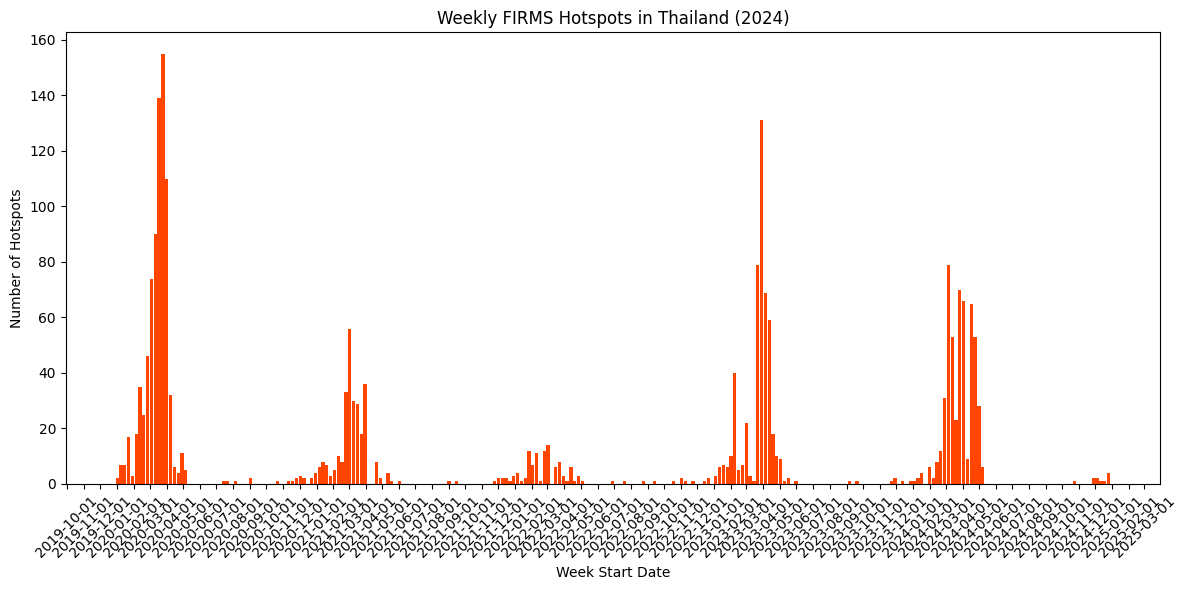

In [ ]:
# Step 6: Export weekly counts to a Pandas DataFrame
weekly_counts_list = weekly_hotspot_counts.getInfo()['features']

weekly_data = [
    {
        'week': datetime.strptime(f['properties']['week'], '%Y-%m-%d'),
        'hotspot': f['properties']['hotspot']
    }
    for f in weekly_counts_list
]
df = pd.DataFrame(weekly_data)

# Step 8: Create a Matplotlib chart
plt.figure(figsize=(12, 6))
plt.bar(df['week'], df['hotspot'], width=6, color='#ff4500', align='center')
plt.title('Weekly FIRMS Hotspots in Thailand (2020-2024)')
plt.xlabel('Week Start Date')
plt.ylabel('Number of Hotspots')
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('weekly_hotspot_counts.png')
plt.show()

In [ ]:
print(weekly_counts_list)


In [65]:
# Step 7: Process DataFrame for LSTM
df['week'] = pd.to_datetime(df['week'])
df = df.set_index('week').sort_index()
df['hotspot'] = pd.to_numeric(df['hotspot'], errors='coerce').fillna(0)

# Extract hotspot data
hotspot = df['hotspot'].values

# Normalize data
scaler = MinMaxScaler()
hotspot_normalized = scaler.fit_transform(hotspot.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 12
X, y = create_sequences(hotspot_normalized, sequence_length)

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [66]:
# Step 8: Build and train LSTM model
model = Sequential()
model.add(LSTM(64, activation='tanh', return_sequences=True, dropout=0.2, recurrent_dropout=0.2, input_shape=(sequence_length, 1)))
model.add(LSTM(32, activation='tanh', dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

/opt/homebrew/Caskroom/miniconda/base/envs/gee/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0152 - val_loss: 0.0174
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0201 - val_loss: 0.0179
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0181 - val_loss: 0.0180
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0084 - val_loss: 0.0166
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0104 - val_loss: 0.0149
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0107 - val_loss: 0.0148
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0132 - val_loss: 0.0147
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0118 - val_loss: 0.0142
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0114 - val_loss: 0.0134
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0096 - val_loss: 0.0124
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0143 - val_loss: 0.0125
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0142 - val_lo

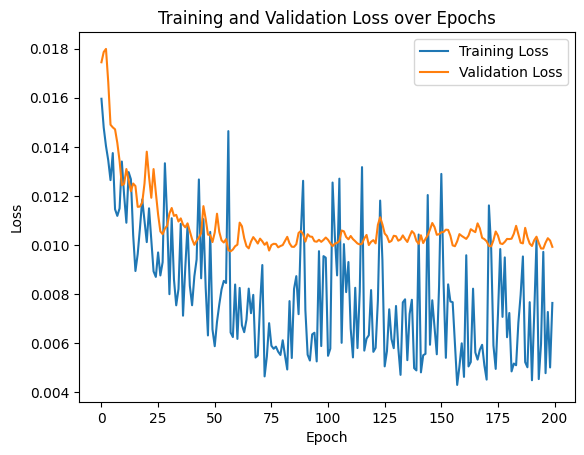

In [67]:
import matplotlib.pyplot as plt

plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


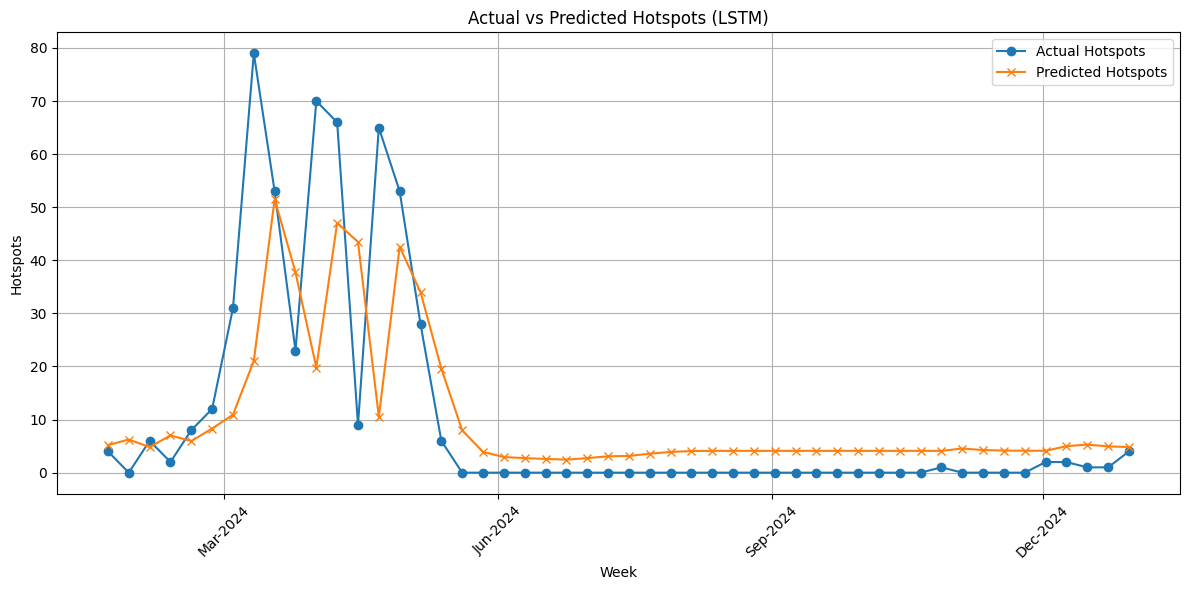

  Model   MAE   RMSE  MAPE (%)    R²
0  LSTM  8.49  15.44       NaN  0.47


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ฟังก์ชันประเมินผลโมเดล
def evaluate_model(model_name, y_true, y_pred, dates, results=[]):
    # แปลงค่าจาก normalize กลับมาเป็น scale เดิม
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    # คำนวณ metric
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    r2 = r2_score(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100 if np.all(y_true_inv != 0) else np.nan

    # เก็บผลลัพธ์
    results.append({
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R²': round(r2, 3)
    })

    # พล็อตกราฟผลการพยากรณ์
    plt.figure(figsize=(12, 6))
    plt.plot(dates, y_true_inv, label='Actual Hotspots', marker='o')
    plt.plot(dates, y_pred_inv, label='Predicted Hotspots', marker='x')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    plt.xlabel("Week")
    plt.ylabel("Hotspots")
    plt.title(f"Actual vs Predicted Hotspots ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results

# ทำนายจากโมเดล
y_pred = model.predict(X_test)

# วันที่ที่ตรงกับ y_test
test_start_index = len(dates) - len(y_test)
date_range = dates[test_start_index:]

# สร้าง list สำหรับเก็บผลหลายโมเดล
results = []

# ประเมินและพล็อต
results = evaluate_model("LSTM", y_test, y_pred, date_range, results)

# แสดงตารางเปรียบเทียบ
df_results = pd.DataFrame(results)
print(df_results)


In [69]:
# แบบที่ 1: ขยายช่วงวันที่ให้ครอบคลุมปีถัดไปอีก 12 เดือน
last_date = pd.to_datetime(dates[-1])
future_dates = pd.date_range(start=last_date, periods=13, freq='MS')[1:]  # เริ่มต้นเดือนถัดจากข้อมูลล่าสุด (รวมทั้งหมด 12 เดือน)

# เตรียม sequence สุดท้ายจากข้อมูลที่ฝึก เพื่อใช้พยากรณ์ลำดับถัดไป
current_sequence = rain[-sequence_length:].reshape(1, sequence_length, 1)

# รายการเก็บค่าที่พยากรณ์แบบ normalize
future_predictions_scaled = []

# พยากรณ์ฝนล่วงหน้า 12 เดือน
for _ in range(12):
    predicted_scaled_next = model.predict(current_sequence)
    future_predictions_scaled.append(predicted_scaled_next[0][0])

    # อัปเดตลำดับใหม่ โดยลบตัวแรก และต่อท้ายด้วยค่าที่พยากรณ์ได้
    current_sequence = np.append(current_sequence[:, 1:, :], predicted_scaled_next.reshape(1, 1, 1), axis=1)

# แปลงค่าฝนที่พยากรณ์จาก normalized กลับไปเป็นค่าจริง (mm)
predicted_rainfall_next_year = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1)).flatten()

# แสดงค่าที่พยากรณ์ได้
print("\nปริมาณฝนที่พยากรณ์ล่วงหน้า 12 เดือน:")
for date, rainfall in zip(future_dates, predicted_rainfall_next_year):
    print(f"{date.strftime('%Y-%m-%d')}: {rainfall:.2f} mm")


# เตรียมข้อมูลสำหรับการพล็อตกราฟ
# สร้างซีรีส์ของข้อมูลฝนจริง
actual_series = pd.Series(scaler.inverse_transform(rain).flatten(), index=pd.to_datetime(dates))

# สร้างซีรีส์ของข้อมูลฝนที่พยากรณ์ไว้สำหรับปีหน้า
predicted_series_next_year = pd.Series(predicted_rainfall_next_year, index=future_dates)

# รวมข้อมูลจริงและข้อมูลที่พยากรณ์ไว้สำหรับการพล็อต
combined_series_next_year = pd.concat([actual_series, predicted_series_next_year])

# พล็อตกราฟแสดงข้อมูลฝนจริงและค่าที่พยากรณ์ไว้ในปีถัดไป
plt.figure(figsize=(14, 7))
plt.plot(actual_series.index, actual_series.values, label='Actual Rainfall')
plt.plot(predicted_series_next_year.index, predicted_series_next_year.values, 'go-', label='Predicted Rainfall (Next Year)') # 'go-' for green circle marker and line
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall Time Series and Next Year Prediction')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'rain' is not defined